In [172]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
from scipy import stats

In [173]:
dt = pd.read_csv('sample_data/AirQualityUCI.csv')

dt.drop(dt.columns[[15,16]], axis=1, inplace = True)

print(dt.info())

dt.dropna(inplace=True) # Ima 9471 - 9357 Na vrijednosti

print(dt.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB
None
            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9357

Pomoću metode drop se miču zadnja dva stupca koji su puni NaN vrijednosti. Kada se njih makne, može se pozvati dropna kako bi se maknili retci s NaN vrijednostima. 357 retaka je imalo vrijednost NaN

In [174]:
variables = dt[['CO(GT)', 'PT08.S1(CO)', 'NO(GT)', 'PT08.S3(NOx)']]

print(variables.describe())

variables.replace(-200, np.nan, inplace = True)
variables.dropna(inplace = True)

print(variables.describe())

            CO(GT)  PT08.S1(CO)      NOx(GT)  PT08.S3(NOx)
count  9357.000000  9357.000000  9357.000000   9357.000000
mean    -34.207524  1048.990061   168.616971    794.990168
std      77.657170   329.832710   257.433866    321.993552
min    -200.000000  -200.000000  -200.000000   -200.000000
25%       0.600000   921.000000    50.000000    637.000000
50%       1.500000  1053.000000   141.000000    794.000000
75%       2.600000  1221.000000   284.000000    960.000000
max      11.900000  2040.000000  1479.000000   2683.000000
            CO(GT)  PT08.S1(CO)      NOx(GT)  PT08.S3(NOx)
count  6944.000000  6944.000000  6944.000000   6944.000000
mean      2.182488  1119.899770   250.625432    816.853399
std       1.440863   218.692183   208.578947    251.854132
min       0.100000   647.000000     2.000000    322.000000
25%       1.100000   956.750000   103.000000    642.000000
50%       1.900000  1085.000000   186.000000    785.500000
75%       2.900000  1254.000000   334.250000    947.0000

<ipython-input-174-2ddd55e4efcb>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variables.replace(-200, np.nan, inplace = True)
<ipython-input-174-2ddd55e4efcb>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variables.dropna(inplace = True)


Describe prikazuje mjere osnovne statistike. Također, pošto je u tablici naznačeno na Kegglu da se -200 vrijednost koristi za nepostojeće vrijednosti, svaki stupac koji ima vrijednost -200 se zamjeni s NaN vrijednostima i dropa. Odabrane su vrijednosti karbon monoksida u zraku i njegove vrijednosti na senzoru, kao i nitrogen oksid i njegova izmjerena vrijednost na senzoru.

Model 1:

Nagib: 0.0057794405561040615
Odsječak: -4.283881456019841

Model 2:

Nagib: -0.556043669096572
Odsječak: 705.3628393923965


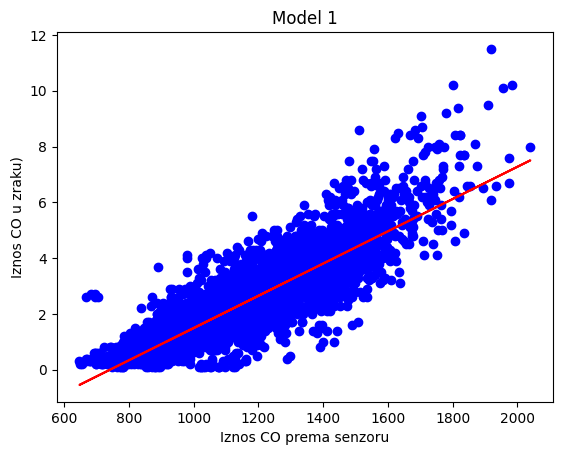

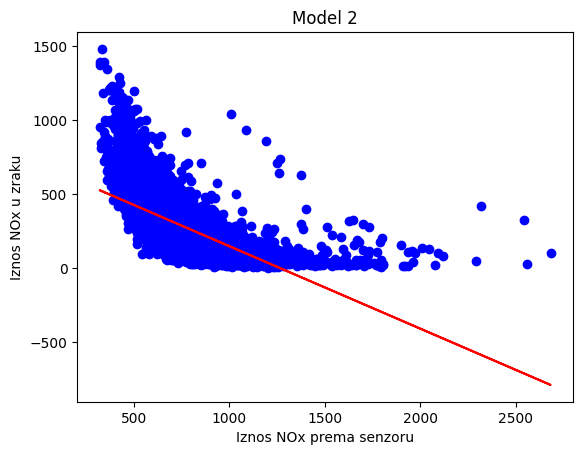

In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X1 = variables['PT08.S1(CO)']
X1 = X1.to_numpy()
y1 = variables['CO(GT)']
y1 = y1.to_numpy()

X1 = X1.reshape(-1, 1)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2)

print('Model 1:\n')
model = LinearRegression()
model.fit(X_train1, y_train1)
# Parametri modela
print(f"Nagib: {model.coef_[0]}")
print(f"Odsječak: {model.intercept_}")

X2 = variables['PT08.S3(NOx)']
X2 = X2.to_numpy()
y2 = variables['NOx(GT)']
y2 = y2.to_numpy()
X2 = X2.reshape(-1, 1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2)

print('\nModel 2:\n')
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
# Parametri modela
print(f"Nagib: {model2.coef_[0]}")
print(f"Odsječak: {model2.intercept_}")


plt.scatter(X_train1, y_train1, color = 'blue')
plt.plot(X_train1, model.predict(X_train1), color = 'red')
plt.title('Model 1')
plt.xlabel('Iznos CO prema senzoru')
plt.ylabel('Iznos CO u zraku)')
plt.show()

plt.scatter(X_train2, y_train2, color = 'blue')
plt.plot(X_train2, model2.predict(X_train2), color = 'red')
plt.title('Model 2')
plt.xlabel('Iznos NOx prema senzoru')
plt.ylabel('Iznos NOx u zraku')
plt.show()


U čeliji gore je napisan kod za 3. i 4. zadatak. Kao što je napisano u tekstu gore, testiraju se povezanosti između mjera karbon monoksida, nitrogen oksida i njihovih vrijednosti izmjerenih na senzorima. Varijable su sve u istom mjerilu tako da se skup podataka nije morao standardizirati. Prema scatter plotu i line plotu možemo zaključiti da prvi graf puno bolje prati linearnost nego drugi.

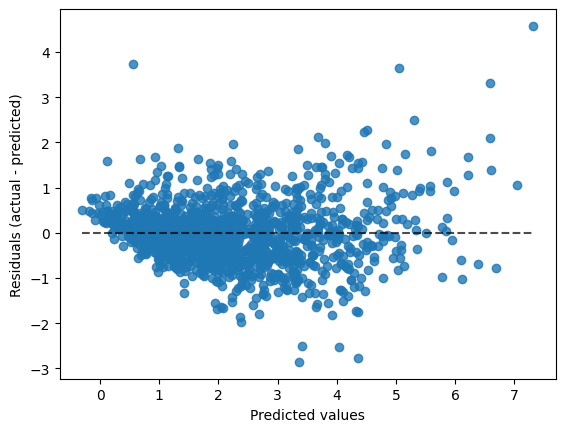

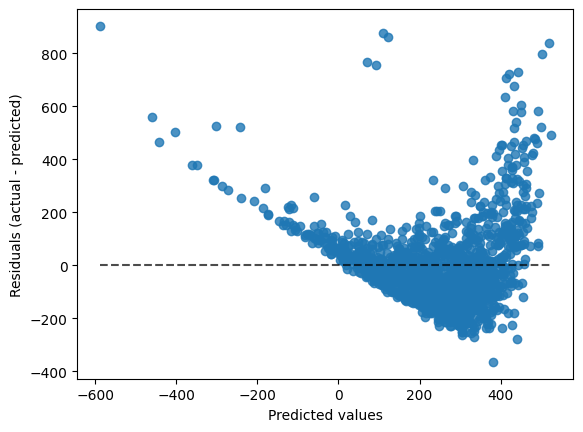

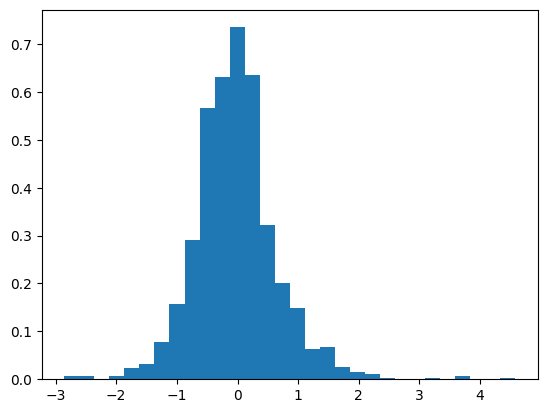

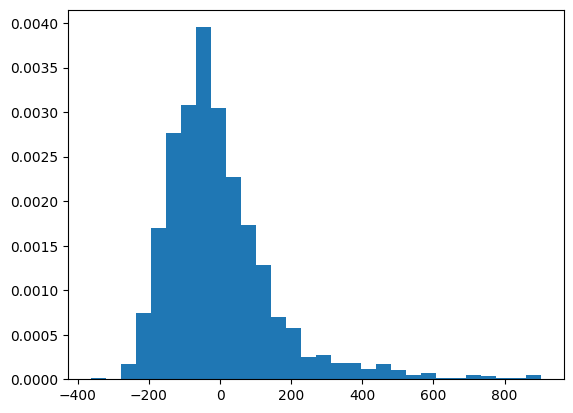

R2 za model 1: 0.781540128049893
R2 za model 2: 0.4018405141028554


In [176]:
# 6
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import r2_score

y_pred = model.predict(X_test1)
y_pred2 = model2.predict(X_test2)

# a)
display = PredictionErrorDisplay(y_true=y_test1, y_pred=y_pred)
display.plot()
plt.show()
display = PredictionErrorDisplay(y_true=y_test2, y_pred=y_pred2)
display.plot()
plt.show()

residual1 = y_test1 - y_pred
residual2 = y_test2 - y_pred2


plt.hist(residual1, 30, density = True,
         histtype ='bar')
plt.show()

plt.hist(residual2, 30, density = True,
         histtype ='bar')
plt.show()

R2_1 = r2_score(y_test1, y_pred)
R2_2 = r2_score(y_test2, y_pred2)

print(f"R2 za model 1: {R2_1}")
print(f"R2 za model 2: {R2_2}")



Rezidualna analiza ispituje odnose između predviđenih i stvarnih vrijednosti podataka. PredictionErrorDisplay iz scklearn biblioteke korištena je za plotanje grafa koji prikazuje razlike između predviđenih i stvarnih vrijednosti na grafu. Također plotan je histogram jer preko njega možemo vidjeti je li je model dobar ukoliko podaci prate normalnu razdiobu.

R2 mjera je bolja za prvi model jer je bliža broju 1 nego drugi model. To znači da prvi model ima bolju linearnu preciznost nego drugi.

In [177]:
res1,_ = stats.pearsonr(X1.flatten(), y1.flatten())
res2,_ = stats.pearsonr(X2.flatten(), y2.flatten())

print(f"Korelacija za model 1: {res1}")
print(f"Korelacija za model 2: {res2}")

Korelacija za model 1: 0.8770075101166454
Korelacija za model 2: -0.6620172205330416


Pearsonov koeficijent je korišten za mjerenje korelacije među varijablama. Koristi se za linearnost. U ovom slučaju za prve dvije varijable možemo zaključiti da postoji pozitivna linearna korelacija između njih što znači da kada jedna varijabla raste i druga raste, dok za drugi model broj nije dovoljno blizu -1 što znači da ne postoji dovoljno dokaza da su podaci linearno povezani na način da kada jedan raste drugi pada.

Zaključak:

U ovoj vježbi istrenirana su dva modela od kojih se može zaključiti da prvi model ima dovoljno dobru linearnu preciznost dok drugi nema dovoljno dobru za predviđanje varijabli.